In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
 
import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv("C:\My projects\ML\Rainfall\Rainfall.csv")
df.head()

,Unnamed: 0,day,pressure,maxtemp,tempture,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,0,1,1025.90,19.9,18.3,16.80,13.1,72,49,yes,9.3,80.01,26.3
1,1,2,1022.01,21.7,18.9,17.20,15.6,81,83,yes,0.6,10.01,25.3
2,2,3,1019.70,20.3,19.3,18.01,18.4,95,91,yes,0.1,20.01,24.2
3,3,4,1018.90,22.3,20.6,19.10,18.8,90,88,yes,1.1,50.01,16.9
4,4,5,1015.90,21.3,20.7,20.20,19.1,88,81,no,2.3,60.01,13.7


In [9]:
df.shape

(999, 13)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     999 non-null    int64  
 1   day            999 non-null    int64  
 2   pressure       999 non-null    float64
 3   maxtemp        999 non-null    float64
 4   tempture       999 non-null    float64
 5   mintemp        999 non-null    float64
 6   dewpoint       999 non-null    float64
 7   humidity       999 non-null    int64  
 8   cloud          999 non-null    int64  
 9   rainfall       999 non-null    object 
 10  sunshine       999 non-null    float64
 11  winddirection  999 non-null    float64
 12  windspeed      999 non-null    float64
dtypes: float64(8), int64(4), object(1)
memory usage: 101.6+ KB


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,999.0,499.000000,288.530761,0.00,249.50,499.00,748.50,998.00
day,999.0,500.000000,288.530761,1.00,250.50,500.00,749.50,999.00
pressure,999.0,1495.508418,288.179580,1011.30,1245.80,1495.30,1744.80,1994.30
maxtemp,999.0,31.592693,9.933536,17.50,22.50,28.90,39.90,50.90
tempture,999.0,22.370170,2.739518,18.30,20.60,21.60,25.20,26.40
mintemp,999.0,20.988769,3.882036,13.10,18.40,20.70,23.40,40.30
dewpoint,999.0,19.944334,3.756762,13.10,17.40,19.60,21.90,37.90
humidity,999.0,82.674675,9.979702,49.00,78.00,85.00,90.00,99.00
cloud,999.0,82.655656,10.137212,49.00,78.00,85.00,90.00,99.00
sunshine,999.0,5.075275,2.234795,0.10,3.40,5.40,6.20,9.50


In [12]:
df.isnull().sum()

Unnamed: 0       0
day              0
pressure         0
maxtemp          0
tempture         0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    0
windspeed        0
dtype: int64

In [13]:
df.columns

Index(['Unnamed: 0', 'day', 'pressure', 'maxtemp', 'tempture', 'mintemp',
       'dewpoint', 'humidity', 'cloud', 'rainfall', 'sunshine',
       'winddirection', 'windspeed'],
      dtype='object')

In [14]:
df.rename(str.strip,
          axis='columns', 
          inplace=True)
 
df.columns

Index(['Unnamed: 0', 'day', 'pressure', 'maxtemp', 'tempture', 'mintemp',
       'dewpoint', 'humidity', 'cloud', 'rainfall', 'sunshine',
       'winddirection', 'windspeed'],
      dtype='object')

In [15]:
for col in df.columns:
   
  # Checking if the column contains
  # any null values
  if df[col].isnull().sum() > 0:
    val = df[col].mean()
    df[col] = df[col].fillna(val)
     
df.isnull().sum().sum()

np.int64(0)

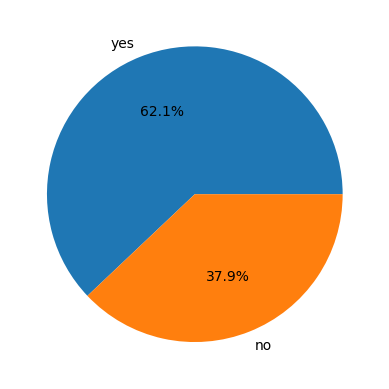

In [16]:
plt.pie(df['rainfall'].value_counts().values,
        labels = df['rainfall'].value_counts().index,
        autopct='%1.1f%%')
plt.show()

In [17]:
df.groupby('rainfall').mean()

,Unnamed: 0,day,pressure,maxtemp,tempture,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
rainfall,,,,,,,,,,,,
no,468.461741,469.461741,1464.945646,31.824538,22.288918,20.817282,19.658417,82.839050,82.224274,5.117942,52.872797,27.838786
yes,517.667742,518.667742,1514.191145,31.450968,22.419839,21.093597,20.119113,82.574194,82.919355,5.049194,51.943871,27.878710


In [18]:
features = list(df.select_dtypes(include = np.number).columns)
features.remove('day')
print(features)

['Unnamed: 0', 'pressure', 'maxtemp', 'tempture', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection', 'windspeed']


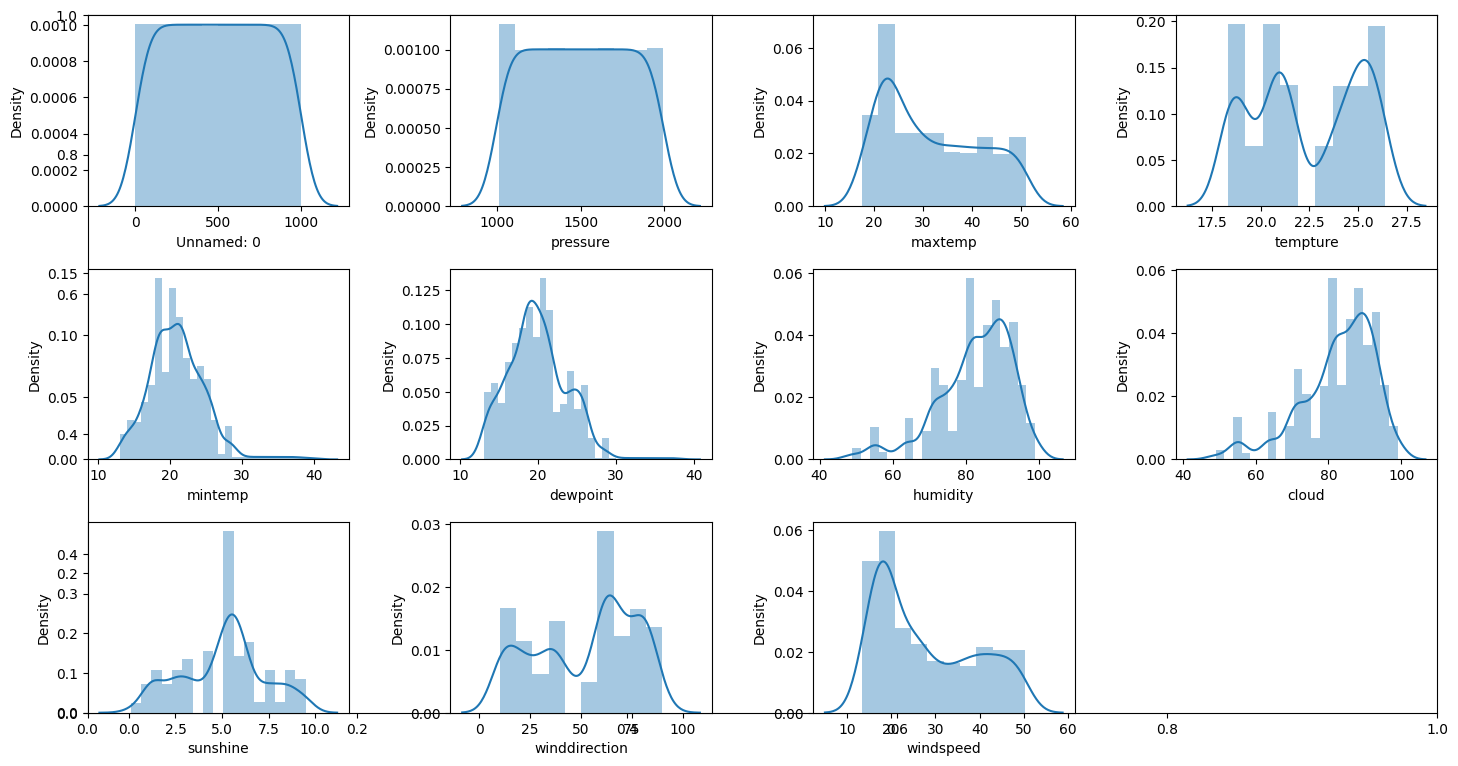

In [19]:
plt.subplots(figsize=(15,8))
 
for i, col in enumerate(features):
  plt.subplot(3,4, i + 1)
  sb.distplot(df[col])
plt.tight_layout()
plt.show()

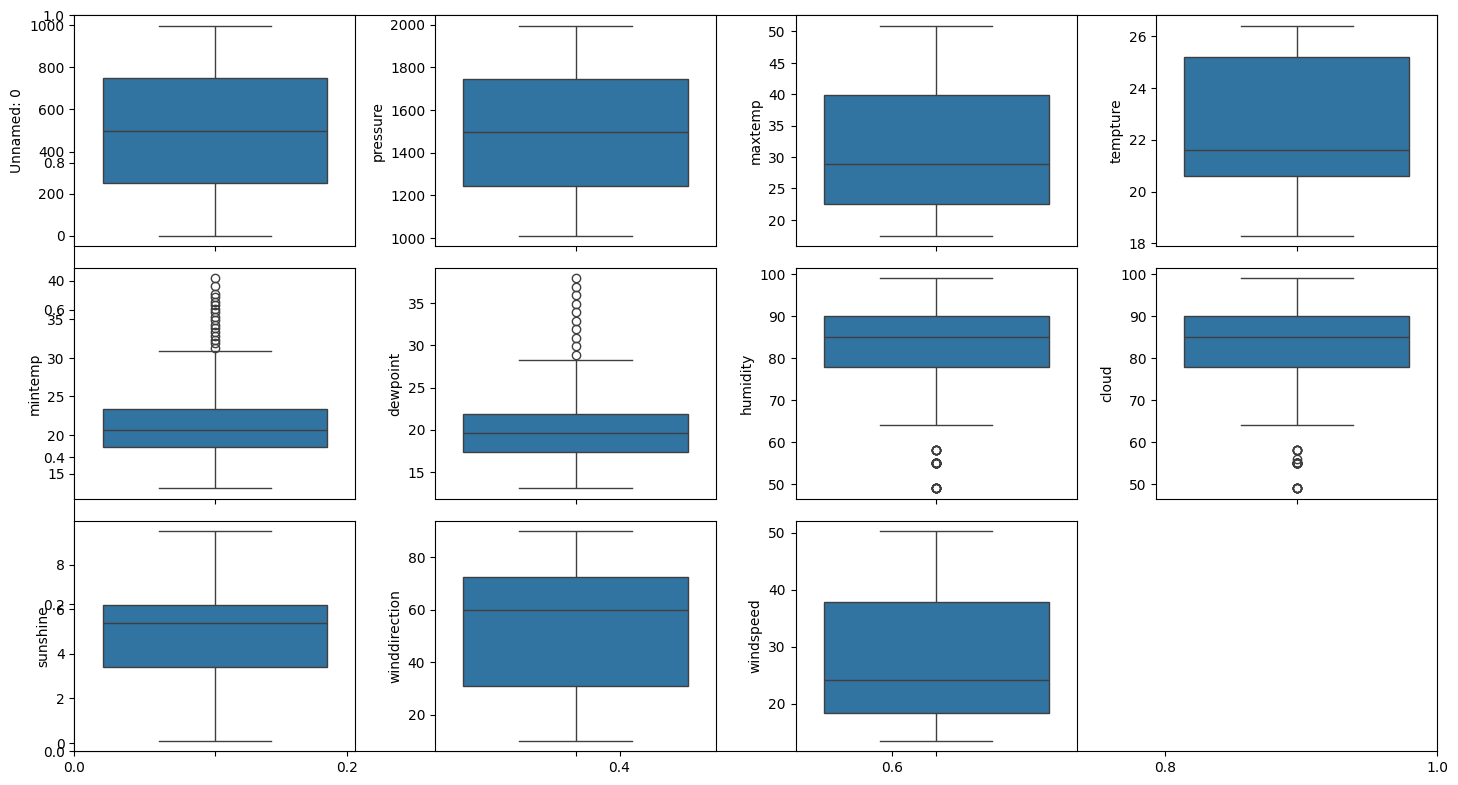

In [20]:
plt.subplots(figsize=(15,8))
 
for i, col in enumerate(features):
  plt.subplot(3,4, i + 1)
  sb.boxplot(df[col])
plt.tight_layout()
plt.show()

In [21]:
df.replace({'yes':1, 'no':0}, inplace=True)

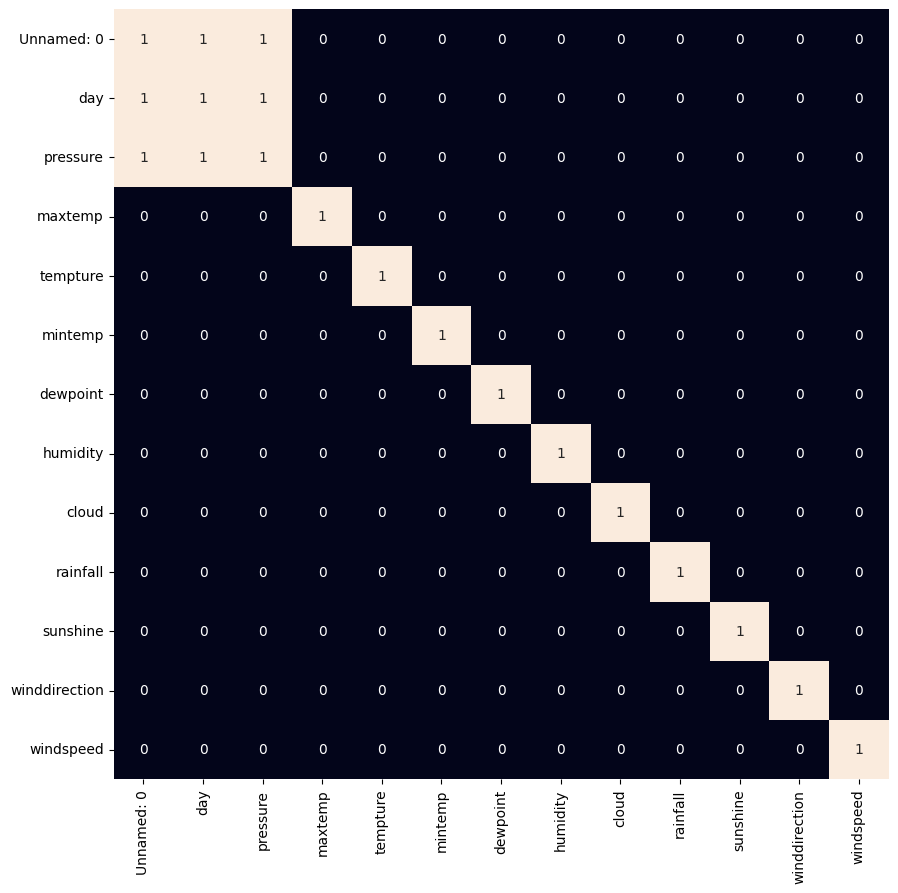

In [22]:
plt.figure(figsize=(10,10))
sb.heatmap(df.corr() > 0.8,
           annot=True,
           cbar=False)
plt.show()

In [23]:
df.drop(['maxtemp', 'mintemp'], axis=1, inplace=True)

In [24]:
features = df.drop(['day', 'rainfall'], axis=1)
target = df.rainfall

In [25]:
X_train, X_val, \
    Y_train, Y_val = train_test_split(features,
                                      target,
                                      test_size=0.2,
                                      stratify=target,
                                      random_state=2)
 
# As the data was highly imbalanced we will
# balance it by adding repetitive rows of minority class.
ros = RandomOverSampler(sampling_strategy='minority',
                        random_state=22)
X, Y = ros.fit_resample(X_train, Y_train)

In [26]:
# Normalizing the features for stable and fast training.
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_val = scaler.transform(X_val)

In [27]:
models = [LogisticRegression(), XGBClassifier(), SVC(kernel='rbf', probability=True)]
 
for i in range(3):
  models[i].fit(X, Y)
 
  print(f'{models[i]} : ')
 
  train_preds = models[i].predict_proba(X) 
  print('Training Accuracy : ', metrics.roc_auc_score(Y, train_preds[:,1]))
 
  val_preds = models[i].predict_proba(X_val) 
  print('Validation Accuracy : ', metrics.roc_auc_score(Y_val, val_preds[:,1]))
  print()

LogisticRegression() : 
Training Accuracy :  0.5662599180541104
Validation Accuracy :  0.5166595925297114

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Training Accuracy :  1.0
Validation Accuracy :  0.525679117147708

SVC(probability=True) : 
Training Accuracy :  0.80187873959417

In [28]:
print(metrics.classification_report(Y_val,models[2].predict(X_val)))

              precision    recall  f1-score   support

           0       0.37      0.38      0.37        76
           1       0.61      0.60      0.60       124

    accuracy                           0.52       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.52      0.52      0.52       200

